In [8]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
from scipy.stats import norm
from datetime import datetime, timedelta

from Database.queries import *
from Features.features import *
from Strategies.strategies import *
from BackTester.backtester import BackTester

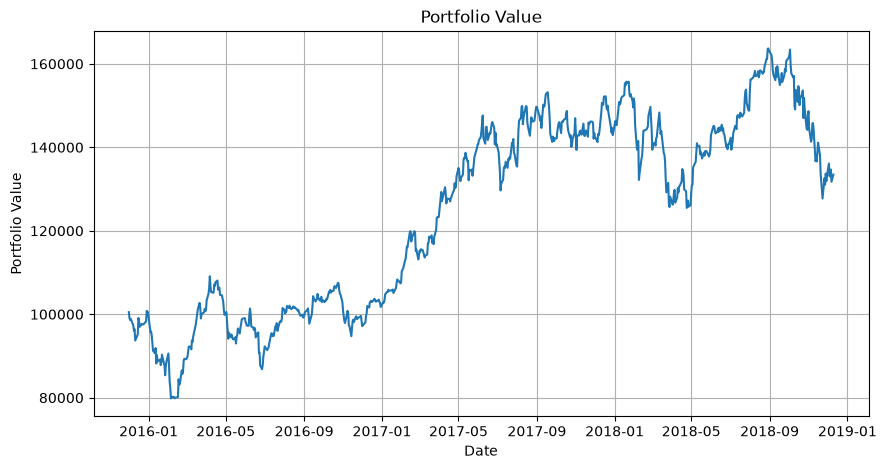

In [26]:
assets = ['AAPL', 'TSLA', 'GOOGL']
window = 252
n = 2
start = "2015-12-01"
end = "2018-12-10"
short_window = 10
long_window = 50

# prices
prices_open = get_prices(assets=assets, field='open', pivot=True)
prices_close = get_prices(assets=assets, field='close', pivot=True)

# strategy
weights1 = momentum_strategy(prices_close, window=window, n=n)
weights2 = MA_strategy(prices_close, long_window, short_window)

bt = BackTester(prices_open, prices_close)
results = bt.run(weights1, start=start, end=end)
bt.plot_portfolio_value()

In [27]:
results['Weights'].value_counts()

AAPL  GOOGL  TSLA
0.5   0.5    0.0     299
      0.0    0.5     270
0.0   0.5    0.5     193
Name: count, dtype: int64

In [21]:
results['Weights']

ticker,AAPL,GOOGL,TSLA
date,,,
2010-12-01,1.0,0.0,0.0
2010-12-02,1.0,0.0,0.0
2010-12-03,1.0,0.0,0.0
2010-12-06,1.0,0.0,0.0
2010-12-07,1.0,0.0,0.0
...,...,...,...
2020-12-04,0.0,0.0,1.0
2020-12-07,0.0,0.0,1.0
2020-12-08,0.0,0.0,1.0
